# Pytorch For Neural Networks

### Pytorch uses the torch.nn.Module class to represent a neural network.

A Module is just a callable function that can be:

* Parameterized by trainable Parameter tensors that the module can list out.
Composed out of children Modules that contribute parameters.
Saved and Loaded by listing named parameters and other attribute buffers.
Pytorch comes with several built-in elementary network modules, like a generic single-layer Linear network, or a generic Sequential composition of other networks, but of course you can write your own Module subclasses by just defining Parameter attributes and using them to implement a computation.

To see how every Module manages its own portion of responsibilities of all the network duties above, we first look at how to use the built-in Linear and Sequential modules.

Using torch.nn.Linear as a Neural Network
The linear layer is not just a good starting example: it is the fundmental workhorse of all neural networks, so as simple as it is, it is worth examining carefully.

torch.nn.Linear implements the function y = Ax + b, which takes m-dimensional input x and produces n-dimensional output y, by multiplying by the n × m matrix A (whose specific values are called the weight) and adding n-dimensional vector b (whose values are called the bias). We can make a Linear network with 3d input and 2d output just like this:

In [1]:
import torch
import random
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
model = torch.nn.Linear(3, 2)
model

Linear(in_features=3, out_features=2, bias=True)

Like any Module, our little network can be run as a function. As expected, when we give it 3-d vector as input, we get a 2-d vector as output.

In [3]:
model(torch.randn(1, 3))

tensor([[-0.2222,  0.1473]], grad_fn=<AddmmBackward>)

In [4]:
model.weight

Parameter containing:
tensor([[-0.0534,  0.3662, -0.3795],
        [-0.3356, -0.1370, -0.1959]], requires_grad=True)

Batchwise processing is assumed in pytorch networks. Notice the double nesting in the vector data above. This is needed because our Linear network is slightly different from a plain matrix-vector multiplication. By convention, pytorch Modules are set up to process data in batches, so to give it a single 3-d vector, instead of passing just a vector, we have passed it a singleton batch containing one vector.

We can instead send in several inputs - here we provide four vectors as inputs. The network then gives us four vectors as outputs:

in the above example we had considered a batchsize of 1

In [5]:
model(torch.randn(32, 3)) # batch_size of 32

tensor([[ 0.9246, -0.1556],
        [ 1.7302, -0.8200],
        [ 0.1913, -0.7546],
        [ 0.5014, -0.3526],
        [ 0.7850, -0.3262],
        [ 0.5013, -0.2845],
        [ 0.7066, -0.3164],
        [ 0.6434, -1.1055],
        [-0.0171, -0.9119],
        [ 0.0880, -0.8295],
        [ 0.8172, -0.3983],
        [ 0.8352, -0.4410],
        [ 1.4170, -0.9651],
        [ 0.8770, -0.8188],
        [ 0.2188,  0.3035],
        [ 0.0695, -1.0178],
        [ 1.2136, -0.9729],
        [ 0.1624, -0.2335],
        [ 0.3258, -1.5448],
        [ 0.3418, -0.9391],
        [-0.3997, -0.7737],
        [ 0.5826, -0.3586],
        [ 0.6445, -1.1699],
        [ 0.6706, -0.6905],
        [ 0.5655, -0.1957],
        [ 2.0510, -0.2860],
        [ 0.5481, -0.7237],
        [-0.4874, -0.2534],
        [ 1.3051, -0.3289],
        [ 0.8341, -0.9151],
        [-0.6871, -1.3963],
        [ 1.2817, -0.5865]], grad_fn=<AddmmBackward>)

Parameters are randomly initializated by default. What strange function is this Linear layer computing? By default pytorch has initialized the weights and bias randomly. We can look at these random parameters directly:

In [6]:
model.weight

Parameter containing:
tensor([[-0.0534,  0.3662, -0.3795],
        [-0.3356, -0.1370, -0.1959]], requires_grad=True)

## Training Example: Optimizing a Linear Layer
To train a network we need to come up with a score for how close we are to the goal. This scalar number is called the objective or the loss.

For example, suppose we would like this network to always output [1, 1] regardless of input. Then a reasonable loss would be the mean squared distance to [1, 1], computed like this:

In [7]:
y_batch = model(torch.randn(32, 3))
loss = ((y_batch - torch.tensor([[1.0, 1.0]])) ** 2).sum(1).mean()
print(f'loss is {loss}')

loss is 3.621107578277588


We can use autograd get gradients to see how small changes in every parameter would impact the loss.

In [8]:
loss.backward()
print(f'weight is {model.weight} and grad is:\n{model.weight.grad}')
print(f'bias is {model.bias} and grad is:\n{model.bias.grad}')

weight is Parameter containing:
tensor([[-0.0534,  0.3662, -0.3795],
        [-0.3356, -0.1370, -0.1959]], requires_grad=True) and grad is:
tensor([[-0.0478,  0.9183, -1.6172],
        [-0.5432, -0.1350, -1.6668]])
bias is Parameter containing:
tensor([ 0.4478, -0.5219], requires_grad=True) and grad is:
tensor([-1.4492, -3.2604])


Simple gradient descent can be done directly. To improve our layer, we can use simple gradient descent with a learning rate of 0.01. That is, we can adjust each parameter by subtracting 0.01 times the gradient. If we do this repeatedly, we should get closer to our objective.

Any time we directly update the network parameters, we need to temporarily disable the autograd machinery using with torch.no_grad().

weight is Parameter containing:
tensor([[ 0.0280,  0.2546, -0.1277],
        [-0.0779,  0.7973, -0.3300]], requires_grad=True)

bias is Parameter containing:
tensor([0.7175, 0.1896], requires_grad=True)



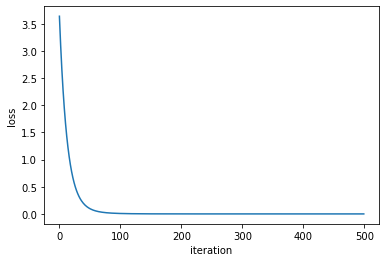

In [9]:
net = torch.nn.Linear(3, 2)
log = []
xb = torch.randn(2, 3)
for _ in range(500):
    y_batch = net(xb)
    loss = ((y_batch - torch.tensor([[1.0, 1.0]])) ** 2).sum(1).mean()
    log.append(loss.item())
    net.zero_grad()
    loss.backward()
    with torch.no_grad():
        for p in net.parameters():
            p[...] -= 0.01 * p.grad
print(f'weight is {net.weight}\n')
print(f'bias is {net.bias}\n')

%matplotlib inline
import matplotlib.pyplot as plt
plt.ylabel('loss')
plt.xlabel('iteration')
plt.plot(log)

# Now lets train a neural network on a near realistic dataset

in order to have good flexibiltity of experimentation we will use the mnist dataset

## Data PreProcessing

In [ ]:
!curl -L https://github.com/narain1/dotfiles/releases/download/data/mnist_png.zip -o mnist_png.zip

In [ ]:
import shutil
shutil.unpack_archive('mnist_png.zip', extract_dir='data')

Now lets create a dataset for the data that we downloaded

## Helper functions

In [ ]:
import os
import mimetypes
from pathlib import Path
from functools import partial
from typing import Optional, Union, Tuple
from fastcore.all import L

join_path = lambda x, y: Path(os.path.join(x, y))

def get_files(root: Union[str, Path], 
            file_type: Union[str, Tuple[str, ...]]=None,
            recursive: Optional[bool]=True, 
            generator: Optional[bool]=False):
    """returns a list of absolute path names for specified path,
    and extension type"""
    files = []
    if file_type: file_type = tuple(file_type)
    if not recursive:
        files.extend([join_path(root, i) for i in 
            os.listdir(root) if str(i).lower().endswith(file_type)])
    else:
        for p, d, fs in os.walk(root):
            if file_type:
                files.extend([join_path(p, f) for f in fs if str(f).lower().endswith(file_type)])
            else:
                files.extend([join_path(p, f) for f in fs])
    return L(files) if bool else iter(files)


get_image_files = partial(get_files, file_type= '.png')

In [ ]:
train_fs = get_image_files('data/training')
test_fs = get_image_files('data/testing')

Now lets get the labels of those images

In [ ]:
fs = random.sample(train_fs, 25)
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(Image.open(fs[k]))
    ax.set_title(fs[k].parent.name)
    ax.axis('off')

In [ ]:
y_train = train_fs.map(lambda x: x.parent.name)
y_test = test_fs.map(lambda x: x.parent.name)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(train_fs, y_train, random_state=2021, shuffle=True, test_size=0.2)

In [ ]:
len(x_train), len(x_val), len(y_train), len(y_val)

### Creating the dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

In [ ]:
class MnistDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.tfms = transforms.Compose([transforms.ToTensor(), 
                    transforms.Normalize((0.406), (0.225))])
        
    def __getitem__(self, idx):
        img = Image.open(self.x[idx])
        img = self.tfms(img)
        return img, torch.tensor(int(self.y[idx]))
    
    def __len__(self): return len(self.x)

In [ ]:
train_ds = MnistDataset(x_train, y_train)
val_ds = MnistDataset(x_val, y_val)

In [ ]:
len(train_ds[0])

In [ ]:
train_ds[0][0].shape

In [ ]:
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

In [ ]:
xb, yb = next(iter(train_dl))

In [ ]:
xb.shape, yb.shape

In [ ]:
def fit(model, loss_func, epochs, opt, train_dl, val_dl):
    for epoch in range(epochs):
        model.train() # helps in freezing batchnorm and dropout
        for k, (xb, yb) in enumerate(train_dl):
            loss = loss_func(model(xb), yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        
        model.eval()
        with torch.no_grad():
            acc_loss, acc_acc = 0.0, 0.0
            for k, (xb, yb) in enumerate(val_dl):
                pred = model(xb)
                acc_loss +=  loss_func(pred, yb)
                acc_acc += (torch.argmax(pred, dim=1)==yb).float().mean()
        n = len(val_dl)
        print(epoch, acc_loss/n, acc_acc/n)
    return acc_loss/n, acc_acc/n

### Optimizer

lets create an sgd optimizer from scratch

the main optimizing function is defined in the step function

1. where we calculate the gradient
2. step lr in the direction of gradient so that we are reducing the loss function

In [ ]:
class SGDOpt():
    def __init__(self, params, lr=0.5): 
        self.params,self.lr=list(params),lr
        
    def step(self):
        with torch.no_grad():
            for p in self.params: p -= p.grad * self.lr

    def zero_grad(self):
        for p in self.params: p.grad.data.zero_()

In [ ]:
from torch import nn
import torch.nn.functional as F

### Using torch.nn.Sequential to Compose Networks
Unlike Linear, most networks are made by composing many smaller networks. The simplest way to do this is chain networks together end-to-end, connecting each output to the next input. For example we can simply compose Linear layers.

Defining a Multilayer Perceptron. Of course, to get something more interesting than another linear function, we need to do something nonlinear between the linear steps. if we add a nonlinearity between each step (for example, if we clamp negative numbers to zero - an operation called ReLU), then we can get a Multilayer Perceptron, which is known to be a universal function approximator, i.e., a family of piecewise-linear functions that can approximate any function.

here we are creating an Convolutional model

In [ ]:
model = nn.Sequential(nn.Conv2d(1, 4, kernel_size=3, padding=1, stride=2),
                      nn.ReLU(),
                      nn.Conv2d(4, 8, kernel_size=3, padding=1, stride=2),
                      nn.ReLU(),
                      nn.Conv2d(8, 16, kernel_size=3, padding=1, stride=2),
                      nn.ReLU(),
                      nn.Conv2d(16, 32, kernel_size=3, padding=1, stride=2),
                      nn.AdaptiveAvgPool2d(1),
                      nn.Flatten(),
                      nn.Linear(32, 10)
                     )

In [ ]:
opt = SGDOpt(model.parameters(), lr=1e-2)
fit(model, F.cross_entropy, 3, opt, train_dl, val_dl)

### Defining forward to Create Custom Networks
Sometimes you will want to hook up network components in a more complicated way than just a sequential operation of predefined components.

For example, ResNet is built on the observation that learning can work much better if, instead of learning an arbitrary linear operation, we learn perturbations of the identity. I.e., have a layer learn to compute a small residual instead of the whole total answer.

To apply the residual trick in our little three-layer network, we cannot just use an overall Sequential: instead we will define the operation by writing our own forward function. It looks like this:

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, padding=1, stride=2)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=3, padding=1, stride=2)
        self.conv3 = nn.Conv2d(8, 16, kernel_size=3, padding=1, stride=2)
        self.conv4 = nn.Conv2d(16, 32, kernel_size=3, padding=1, stride=2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, 10)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(F.relu(self.conv4(x)))
        return self.fc(x.view(x.shape[0], -1))

In [ ]:
model = CNN()
opt = SGDOpt(model.parameters(), lr=1e-2)
fit(model, F.cross_entropy, 3, opt, train_dl, val_dl)

### Inbuilt Optimizer

we can use pytorch own inbuilt optimizer instead of using our own SGD optimizer

* like we can see using a better optimizer speeds up our convergence and improves the accuracy of our model

In [ ]:
from torch import optim

model = CNN()
opt = optim.Adam(model.parameters(), lr=1e-2)
fit(model, F.cross_entropy, 3, opt, train_dl, val_dl)

## Other Module tricks
* **torch.nn.Parameter** wraps trainable parameters. In the __init__() method, you can define more tensors as parameters to be optimized, by wrapping parameter tensors with a torch.nn.Parameter before setting the attribute. See the pytorch Linear source code to see an example. (In that code, the in_features and out_features attributes are just ordinary numbers that are not trainable, but weight and bias are wrapped in Parameter objects to mark them as trainable tensors.)
* **module.training** allows special behavior during training. Some modules behave differently at training time than at inference time. For example, a Dropout layer will drop half the channels and amplify the other half randomly during training, but at inference, for better performance, it will include all the channels. To support this sort of trick, there is a module.train() method to put a module (recursively) into training mode and a module.eval() to put it into inference mode. The module.training boolean tells which mode is current. See the pytorch dropout source code to see the training flag in use.
* **buffers** can be learned without the optimizer. Not every attribute of a module needs to be trainable by the optimizer. Some attributes can be learned in a different way, for example, by observing and averaging statistics observed during training time. The most famous example of this is the Batchnorm layer, which observes mean and variance during training, and accumulates statistics to enforces zero mean and unit variance. See the pytorch batchnorm module source code for an example of using buffers which are not optimized by the optimizer.
* Predefined model architectures are available; for example, `torchvision.models.resnet18(num_classes=100)` will create a ResNet-18 classifier model, configured to do a 100-way classification of images. See torchvision.models documentation for the standard torchvision model zoo.


`Exercise`

1. try training resnet18 on the same data